## Assignment 2: Time Series Forecasting

### Ky Cuong Pham , a1906313, Version 03

#### Follow detail instructions in the assignment specification and use these heading for implementation and discussion

### 1. Paper evaluation

(Candanedo, LM, Feldheim, V & Deramaix, D 2017, 'Data driven prediction models of energy use of appliances in a low-energy house', Energy and buildings, vol. 140, pp. 81-97.)
https://myuni.adelaide.edu.au/courses/105130/files/16388685?wrap=1

In [29]:
import json

import pandas as pd 
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams

import statsmodels.api as sm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data_utils

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data_utils
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

### 2. Analyse and visualise the Time Series

In [30]:
data = pd.read_csv('energydata_complete.csv')
df = data.copy()
df = df[['Appliances', 'date']]
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)
df.head()

,Appliances
date,
2016-02-14 00:00:00,50
2016-02-14 00:10:00,50
2016-02-14 00:20:00,60
2016-02-14 00:30:00,40
2016-02-14 00:40:00,60


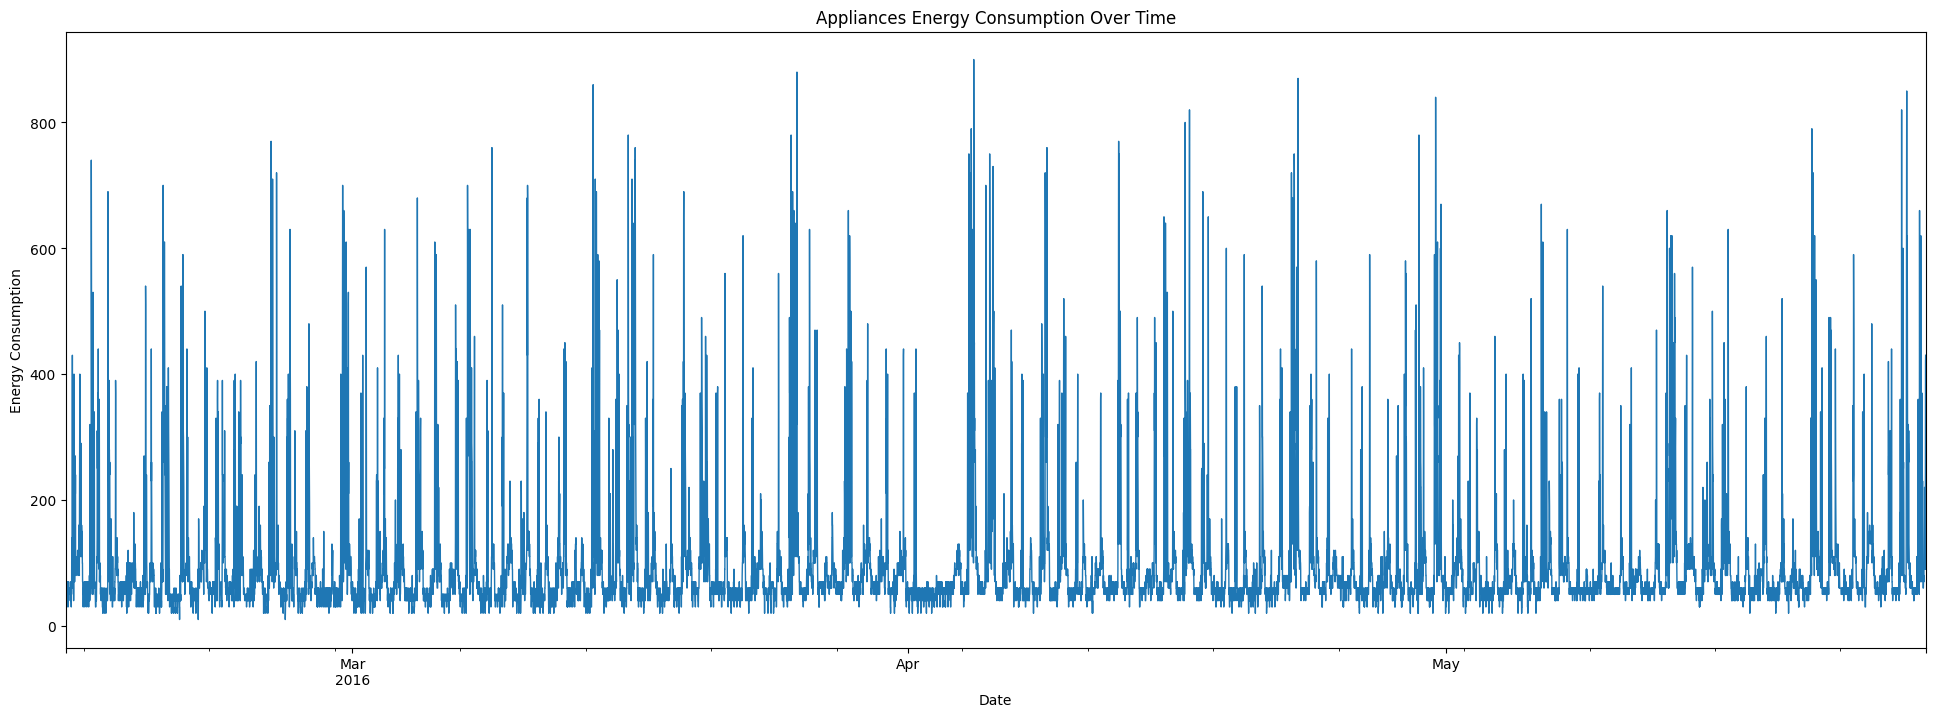

In [31]:
df['Appliances'].plot(figsize=(24, 8), title='Appliances Energy Consumption Over Time', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.show()

As can be seen above, the time series does not yield any obvious trend on energy usage (Appliances) overtime. However, the absence of pattern does not necessarily imply that the data is stable. For further stationary checking, let's plot the simple moving average

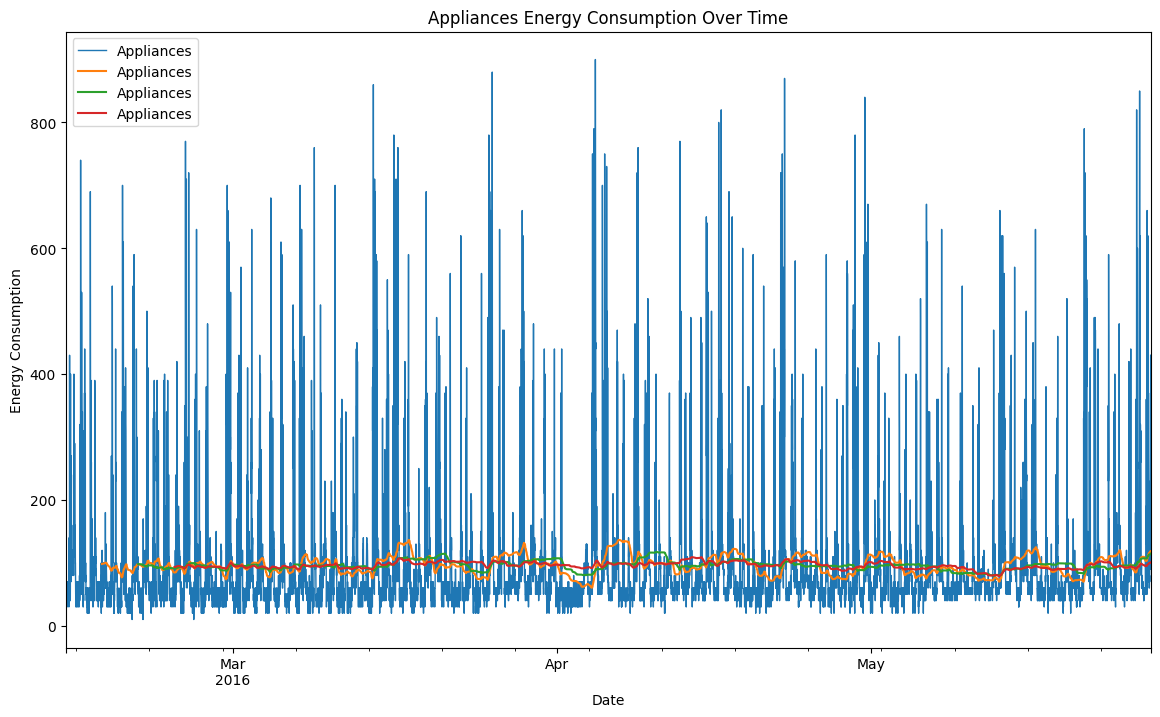

In [32]:
df_sma_500 = df['Appliances'].rolling(window=500).mean()
df_sma_1000 = df['Appliances'].rolling(window=1000).mean()
df_sma_1500 = df['Appliances'].rolling(window=1500).mean()

df['Appliances'].plot(figsize=(14, 8), title='Appliances Energy Consumption Over Time', linewidth=1)
df_sma_500.plot()
df_sma_1000.plot()
df_sma_1500.plot()
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.legend()
plt.show()

Even with averaging, the series is still stable, suggesting the series may already be stationary

### 3. Pre-process the data

In [33]:
from sklearn.preprocessing import MinMaxScaler
#Spliting
train_dev_size = int(len(df) * 0.75)

df_train_dev = df.iloc[:train_dev_size] 
df_test = df.iloc[train_dev_size:]

train_size = int(len(df_train_dev) * 0.8)
df_train = df_train_dev.iloc[:train_size]
df_dev = df_train_dev.iloc[train_size:]

scaler = MinMaxScaler(feature_range =(0, 1))
scaled_train = scaler.fit_transform(df_train['Appliances'].values.reshape(-1, 1))
scaled_train = scaled_train.flatten()

scaled_dev = scaler.transform(df_dev['Appliances'].values.reshape(-1, 1))
scaled_dev = scaled_dev.flatten()

scaled_test = scaler.transform(df_test['Appliances'].values.reshape(-1, 1))
scaled_test = scaled_test.flatten()

print(f"scaled_train shape: {scaled_train.shape}")
print(f"scaled_dev shape: {scaled_dev.shape}")
print(f"scaled_test shape: {scaled_test.shape}")

scaled_train shape: (8964,)
scaled_dev shape: (2241,)
scaled_test shape: (3736,)


### 4. Model training and selection

In [34]:
# Time series techniques (cite Module 5 Online learning/chapter 12)
# 1. Decomposition
# 2. Smoothing based techniques
# 3. Regression based techniques
# 4. machine learning-based techniques

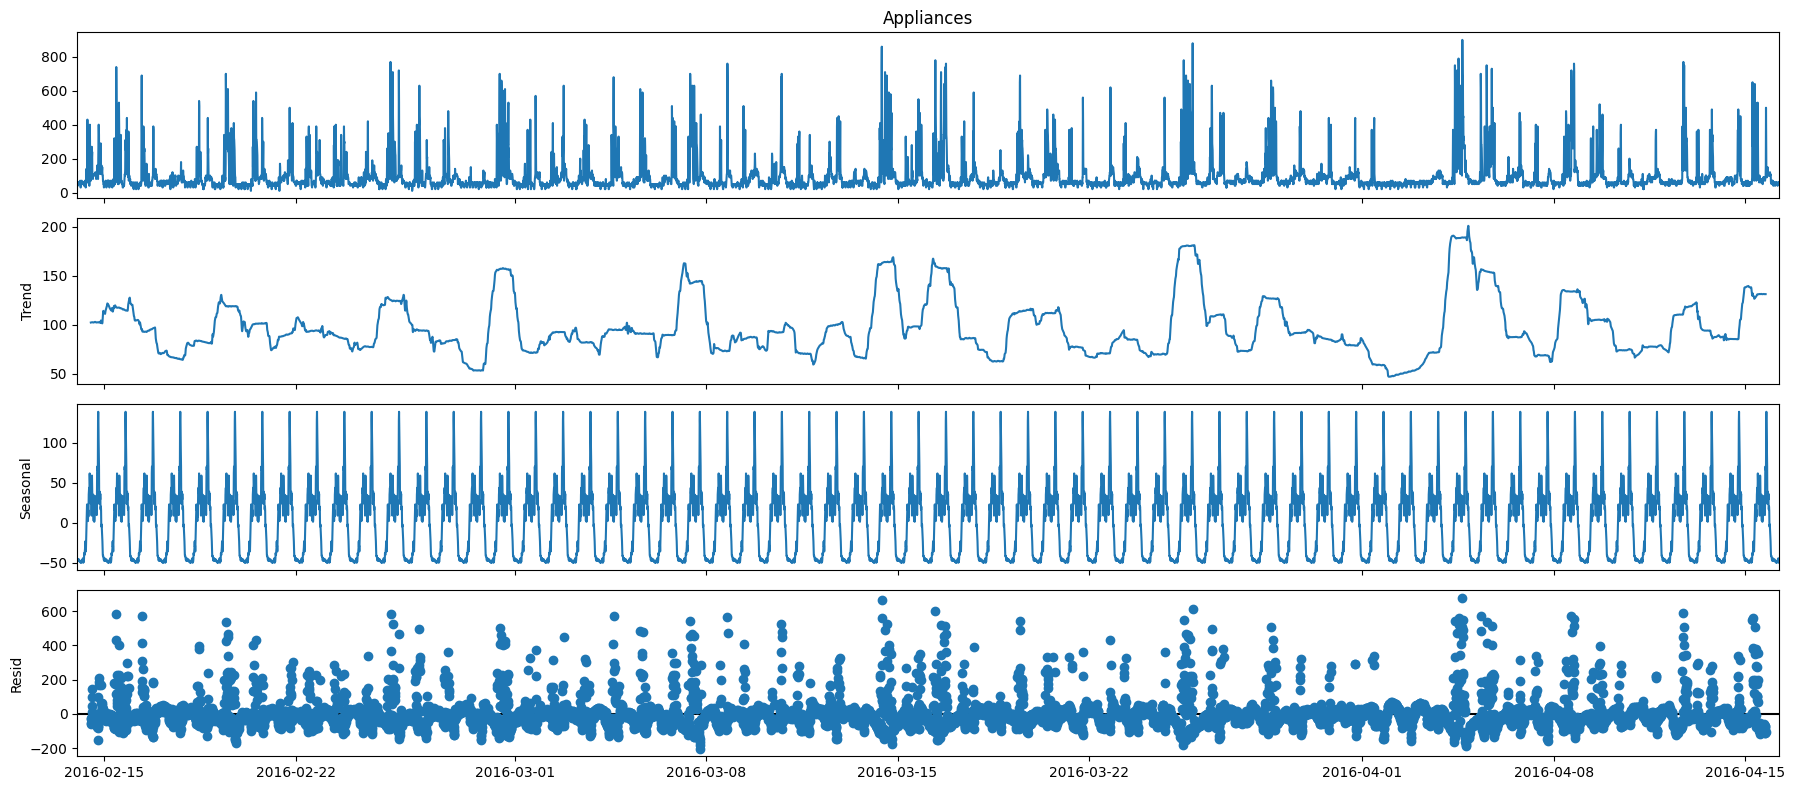

In [35]:
# Decomposition

rcParams['figure.figsize'] = 18, 8

decomposition = seasonal_decompose(df_train['Appliances'], model='additive', period=144) #24*60/10=144 Daily data
decomposition.plot()
plt.show()

residual = decomposition.resid
seasonal = decomposition.seasonal
trend = decomposition.trend

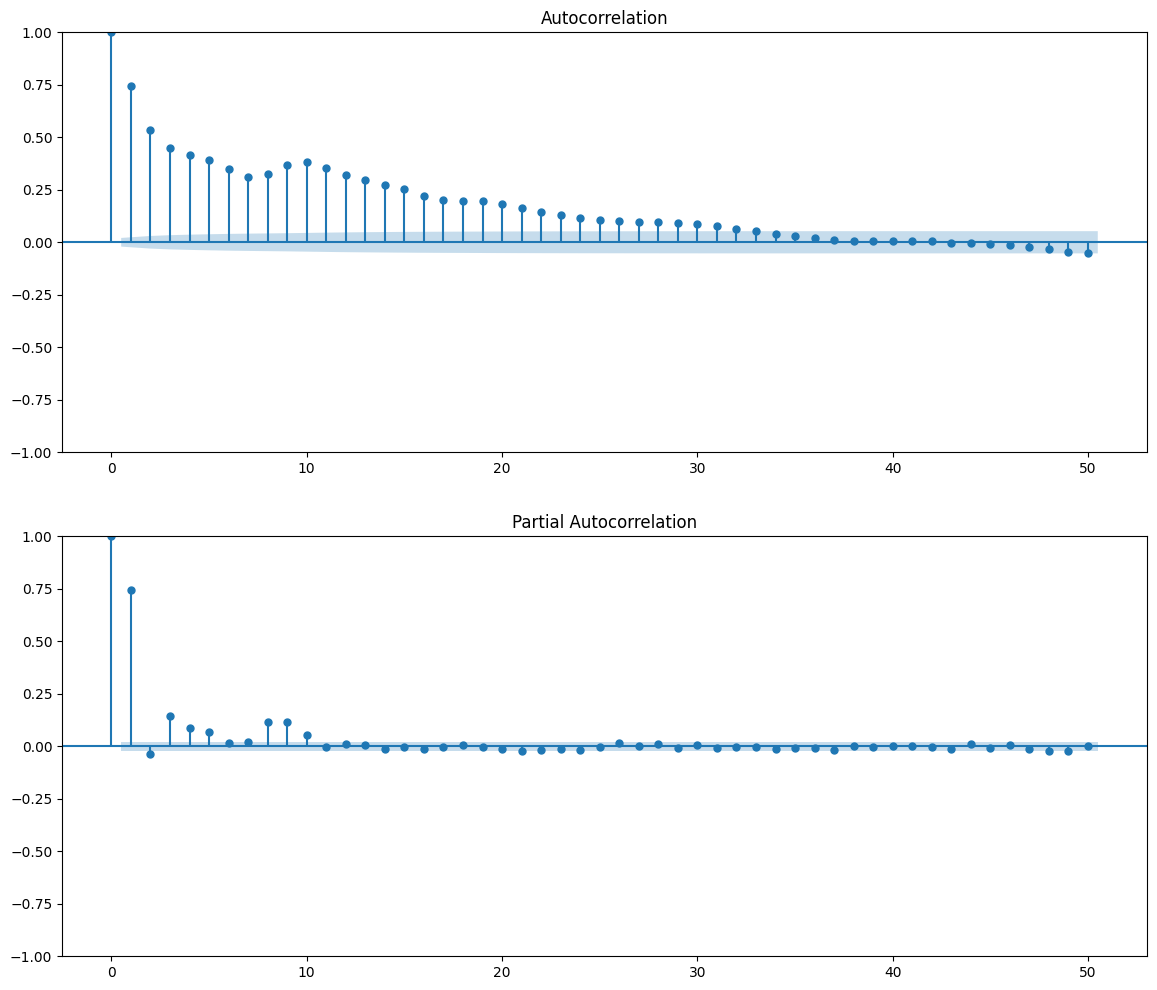

In [36]:
# As dicussed before, the time series is stationary, so we will choose d = 0 for the ARIMA model
# We will use the ACF and PACF plots to determine the values of p and q

# Finding p and q 

fig, ax = plt.subplots(2, 1, figsize=(14, 12))

plot_acf(df_train['Appliances'], lags=50, ax=ax[0])
plot_pacf(df_train['Appliances'], lags=50, ax=ax[1])
plt.show()

p = q = 3

                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                 8964
Model:                 ARIMA(3, 0, 3)   Log Likelihood              -49206.789
Date:                Sat, 15 Mar 2025   AIC                          98429.577
Time:                        17:15:06   BIC                          98486.385
Sample:                    02-14-2016   HQIC                         98448.911
                         - 04-16-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0191      4.380     -0.004      0.997      -8.604       8.566
ar.L1          0.5095      0.239      2.133      0.033       0.041       0.978
ar.L2          0.6060      0.314      1.932      0.0

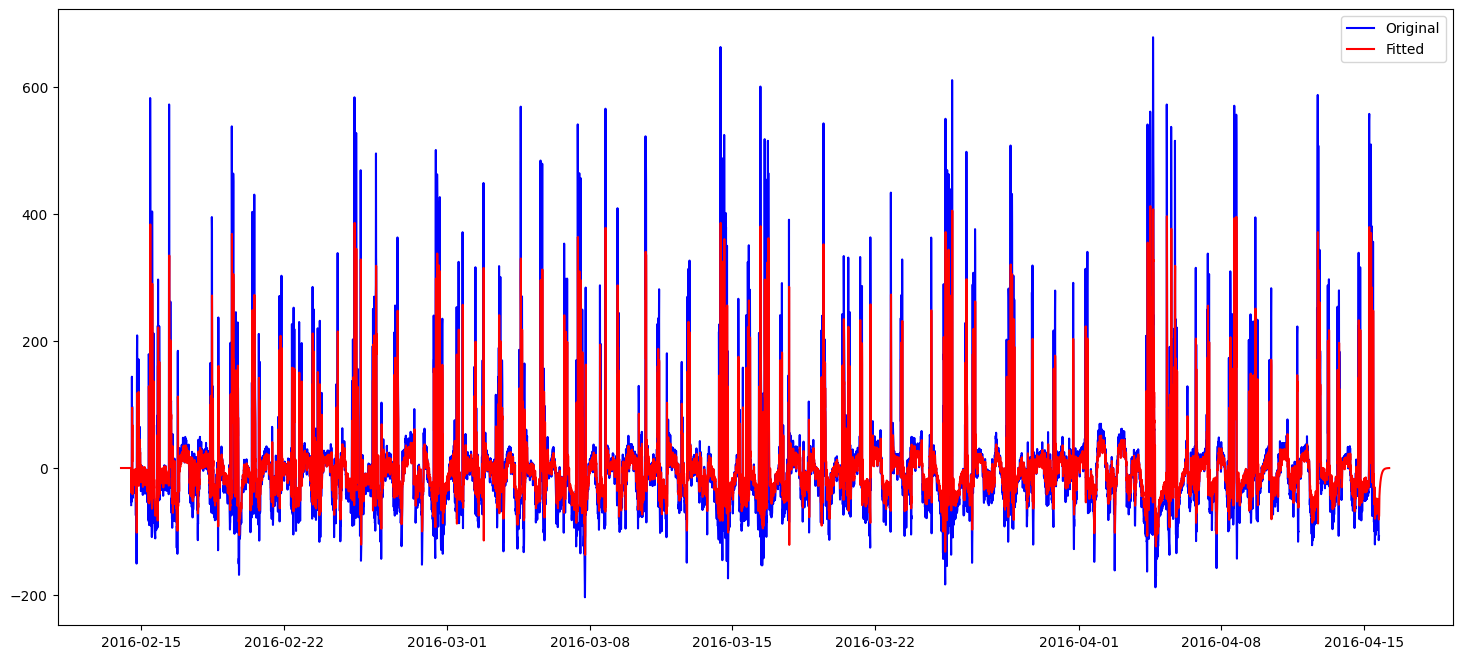

In [41]:
model_arima = sm.tsa.arima.ARIMA(residual, order=(3, 0, 3)) #p=3, d=0(because it is stationary), q=3
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())
plt.plot(residual, label='Original', color='blue')
plt.plot(model_arima_fit.fittedvalues, color='red', label='Fitted')
plt.legend()
plt.show()

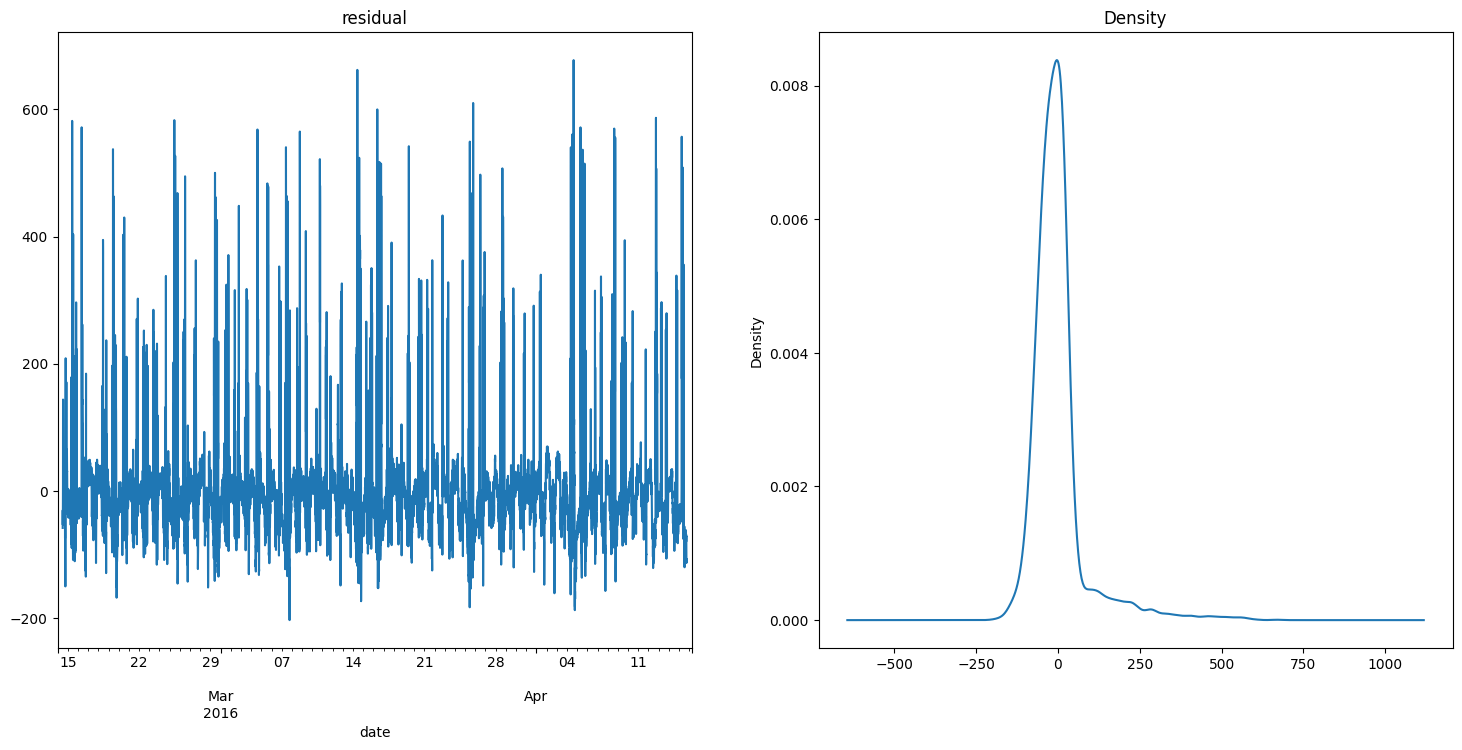

In [28]:
fig, ax = plt.subplots(1,2)
residual.plot(title='residual', ax=ax[0])
residual.plot(title='Density', kind='kde', ax=ax[1])
plt.show()

In [56]:
df_dev

,Appliances
date,
2016-04-16 06:00:00,60
2016-04-16 06:10:00,50
2016-04-16 06:20:00,50
2016-04-16 06:30:00,50
2016-04-16 06:40:00,60
...,...
2016-05-01 18:40:00,120
2016-05-01 18:50:00,110
2016-05-01 19:00:00,120


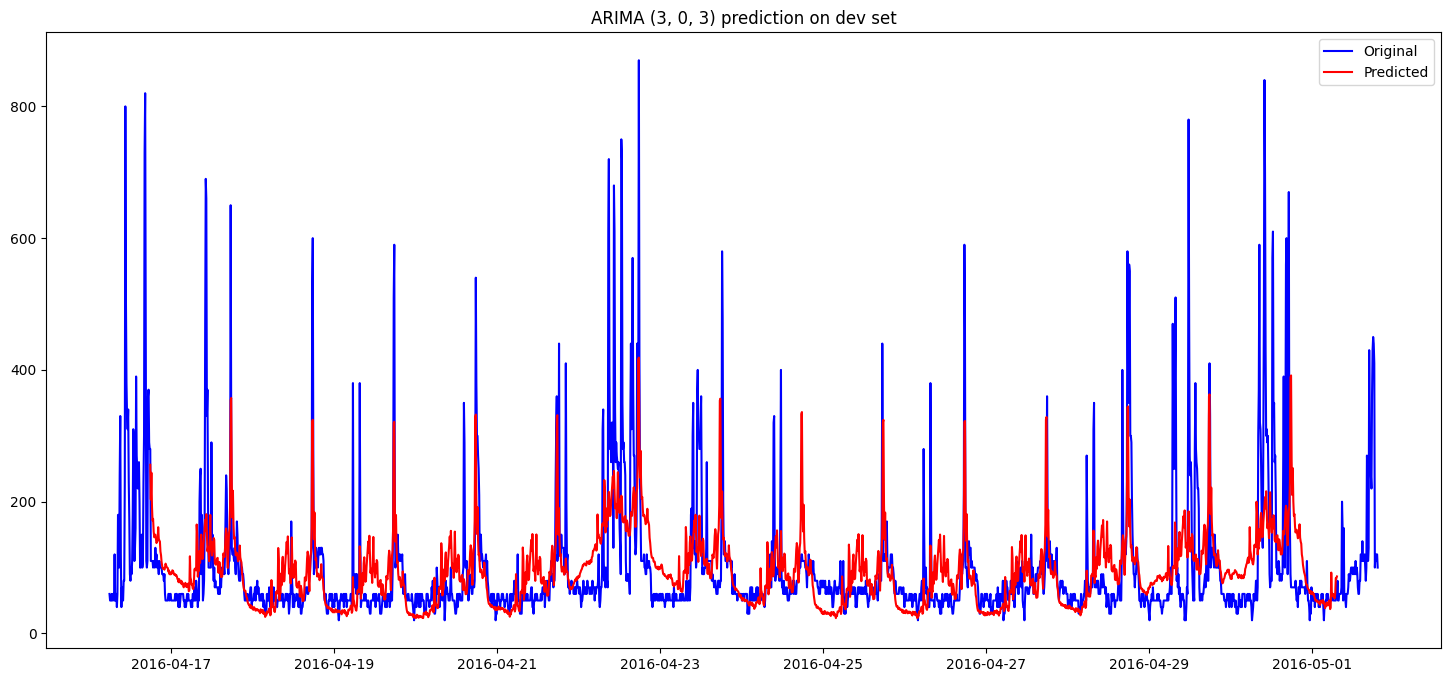

In [61]:
# First, we need to decompose the dev set similar to the training set
dev_decomposition = seasonal_decompose(df_dev['Appliances'], model='additive', period=144)
dev_residual = dev_decomposition.resid
dev_seasonal = dev_decomposition.seasonal
dev_trend = dev_decomposition.trend

# Drop NaN values from residual
dev_residual = dev_residual.interpolate(method='linear') 

# Now we need to ensure we use the same index for all components
common_index = dev_residual.index

# Make predictions using the fitted ARIMA model
dev_predictions_residual = model_arima_fit.forecast(steps=len(dev_residual))

# Align indices before adding components
# Convert the forecast to a Series with the same index as dev_residual
dev_predictions_residual = pd.Series(dev_predictions_residual, index=common_index)

# Use the same index for all components
dev_predictions_complete = dev_predictions_residual + dev_seasonal.loc[common_index] + dev_trend.loc[common_index]

# Plotting
plt.figure(figsize=(18, 8))
plt.plot(df_dev['Appliances'].loc[common_index], label='Original', color='blue')
plt.plot(dev_predictions_complete, label='Predicted', color='red')
plt.title('ARIMA (3, 0, 3) prediction on dev set')
plt.legend()
plt.show()

Because period, so we have missing values at the end and the b

In [72]:
dev_trend

date
2016-04-16 06:00:00   NaN
2016-04-16 06:10:00   NaN
2016-04-16 06:20:00   NaN
2016-04-16 06:30:00   NaN
2016-04-16 06:40:00   NaN
                       ..
2016-05-01 18:40:00   NaN
2016-05-01 18:50:00   NaN
2016-05-01 19:00:00   NaN
2016-05-01 19:10:00   NaN
2016-05-01 19:20:00   NaN
Name: trend, Length: 2241, dtype: float64

In [67]:
df_dev.shape

(2241, 1)

In [68]:
common_index

DatetimeIndex(['2016-04-16 06:00:00', '2016-04-16 06:10:00',
               '2016-04-16 06:20:00', '2016-04-16 06:30:00',
               '2016-04-16 06:40:00', '2016-04-16 06:50:00',
               '2016-04-16 07:00:00', '2016-04-16 07:10:00',
               '2016-04-16 07:20:00', '2016-04-16 07:30:00',
               ...
               '2016-05-01 17:50:00', '2016-05-01 18:00:00',
               '2016-05-01 18:10:00', '2016-05-01 18:20:00',
               '2016-05-01 18:30:00', '2016-05-01 18:40:00',
               '2016-05-01 18:50:00', '2016-05-01 19:00:00',
               '2016-05-01 19:10:00', '2016-05-01 19:20:00'],
              dtype='datetime64[ns]', name='date', length=2241, freq=None)

In [54]:
dev_predictions_complete

date
2016-04-16 18:00:00    256.081417
2016-04-16 18:10:00    203.343000
2016-04-16 18:20:00    243.972638
2016-04-16 18:30:00    193.305979
2016-04-16 18:40:00    171.343023
                          ...    
2016-05-01 06:40:00           NaN
2016-05-01 06:50:00           NaN
2016-05-01 07:00:00           NaN
2016-05-01 07:10:00           NaN
2016-05-01 07:20:00           NaN
Length: 2097, dtype: float64

In [73]:
# Calculate error metrics
import numpy as np
from sklearn import metrics

# Ensure both observed and predicted values are aligned and non-NaN
valid_mask = ~np.isnan(df_dev['Appliances']) & ~np.isnan(dev_predictions_complete)

# Filter non-NaN values
y_true = df_dev['Appliances'][valid_mask]
y_pred = dev_predictions_complete[valid_mask]

# Calculate RMSE and MAPE
rmse_arima = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
mape_arima = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'RMSE: {rmse_arima}')
print(f'MAPE: {mape_arima}')

RMSE: 79.0381577247563
MAPE: 54.391409215575635


### LTSM

In [77]:
# build LSTM Model for time series forecasting using Pytorch
def create_dataset(dataset, look_back=1):
    """
    Create a dataset where X is a sequence of look_back values and y is the next value
    """
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        feature = dataset[i:(i + look_back)]
        dataX.append(feature)
        target = dataset[i + look_back]  # Just the next value, not a sequence
        dataY.append(target)
    return torch.Tensor(dataX), torch.Tensor(dataY).unsqueeze(1)  # Add dimension to y for [batch, 1]

In [78]:
lookback = 5  # Increased lookback for better context
X_train, y_train = create_dataset(scaled_train, lookback)
X_dev, y_dev = create_dataset(scaled_dev, lookback)

# Reshape input to be [samples, time steps, features]
X_train = X_train.unsqueeze(-1)  # Shape becomes [batch, seq_len, features]
X_dev = X_dev.unsqueeze(-1)

print(f"X_train shape: {X_train.shape}")  # Should be [samples, lookback, 1]
print(f"y_train shape: {y_train.shape}")  # Should be [samples, 1]
print(f"X_dev shape: {X_dev.shape}")
print(f"y_dev shape: {y_dev.shape}")


X_train shape: torch.Size([8959, 5, 1])
y_train shape: torch.Size([8959, 1])
X_dev shape: torch.Size([2236, 5, 1])
y_dev shape: torch.Size([2236, 1])


In [ ]:
from tqdm import tqdm

class MyLSTM(nn.Module):
    def __init__(self, input_size, hidden_layer_size, output_size, num_layers):
        super(MyLSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, X):
        batch_size = X.shape[0]

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_layer_size).to(X.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_layer_size).to(X.device)

        # Forward pass through LSTM
        lstm_out, _ = self.lstm(X, (h0, c0))
        
        # Apply the linear layer to the last time step's output
        predictions = self.linear(lstm_out[:, -1, :])
        
        return predictions  # Shape: [batch_size, output_size]



# Model parameters
input_size = 1
hidden_layer_size = 100
output_size = 1
num_layers = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyLSTM(input_size, hidden_layer_size, output_size, num_layers)

# Move model to the device
print(f"Device: {device}")
model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_dev = X_dev.to(device)
y_dev = y_dev.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

loader = data_utils.DataLoader(data_utils.TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

training_history = []

n_epochs = 100
for epoch in tqdm(range(n_epochs)):
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    epoch_loss = sum(batch_losses) / len(batch_losses)
    
    if epoch % 20 == 0:
        print(f'Epoch: {epoch}, Loss: {epoch_loss:.6f}')
    
    # Evaluation step
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train)
        y_pred_dev = model(X_dev)
        loss_train = loss_fn(y_pred_train, y_train)
        loss_dev = loss_fn(y_pred_dev, y_dev)
        
        training_history.append((loss_train.item(), loss_dev.item()))
        
        if epoch % 20 == 0:
            print(f'Epoch: {epoch}, Train Loss: {loss_train.item():.6f}, Dev Loss: {loss_dev.item():.6f}')

# Prepare data for plotting
train_losses = [loss_train for loss_train, _ in training_history]
dev_losses = [loss_dev for _, loss_dev in training_history]

# Save to JSON
training_history_dict = {
    'train': train_losses,
    'dev': dev_losses
}

with open('training_history.json', 'w') as f:
    json.dump(training_history_dict, f)

# Save the model
torch.save(model.state_dict(), 'lstm_model.pth')

# Plot the training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(dev_losses, label='Dev Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


Device: cuda


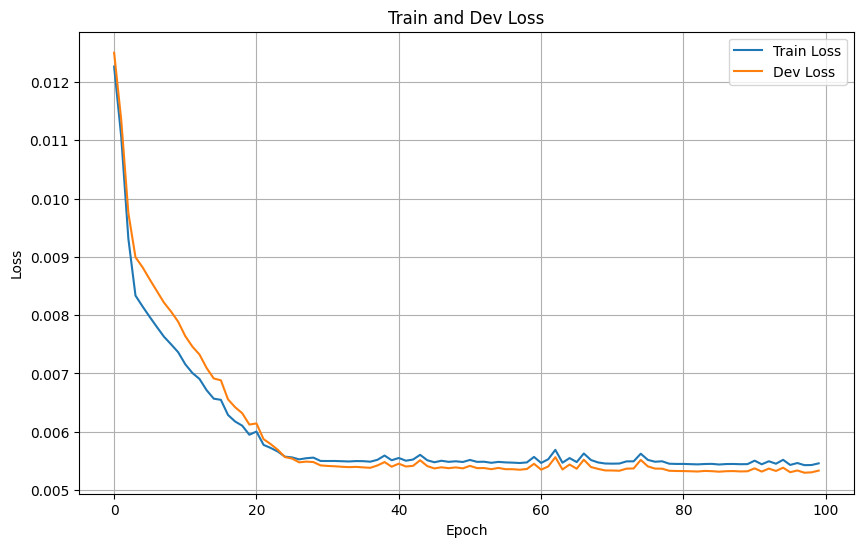

In [81]:
# Model parameters
input_size = 1
hidden_layer_size = 100
output_size = 1
num_layers = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyLSTM(input_size, hidden_layer_size, output_size, num_layers)

# Move model to the device
print(f"Device: {device}")
model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_dev = X_dev.to(device)
y_dev = y_dev.to(device)

#load the model
model.load_state_dict(torch.load('lstm_model.pth'))
model.eval()

# plot the training history 
with open('training_history.json', 'r') as f:
    training_history_dict = json.load(f)

train_losses = training_history_dict['train']
dev_losses = training_history_dict['dev']

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(dev_losses, label='Dev Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Dev Loss')
plt.legend()
plt.grid(True)

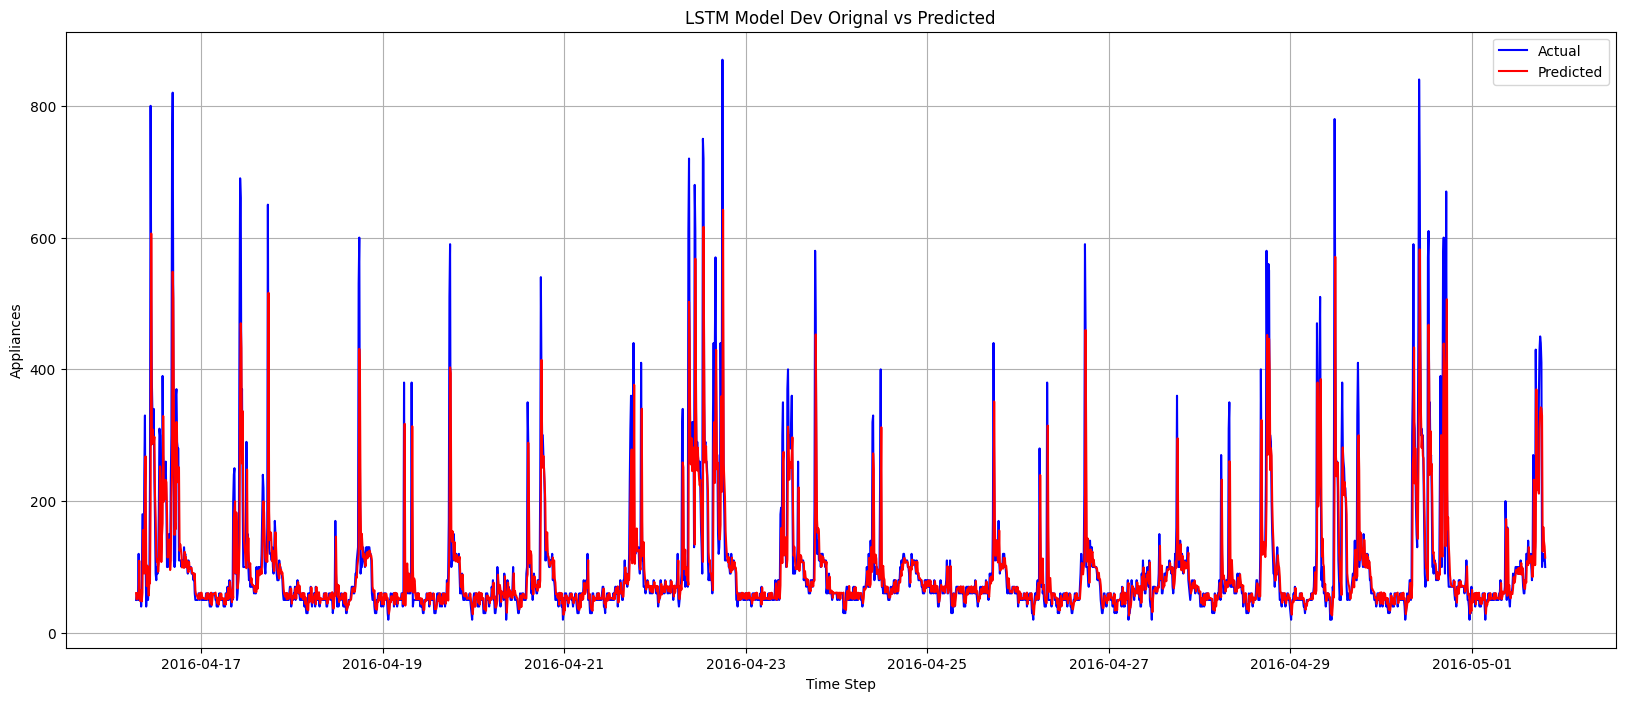

In [85]:
# Ensure model is in evaluation mode
model.eval()

# Make predictions
with torch.no_grad():
    y_pred_dev = model(X_dev)

# Move predictions back to CPU and convert to NumPy
y_pred_dev = y_pred_dev.to('cpu').numpy()
# y_dev = y_dev.to('cpu').numpy()

# Reshape to match the expected input of inverse_transform
y_pred_dev_inv = scaler.inverse_transform(y_pred_dev)
y_dev_inv = scaler.inverse_transform(y_dev)

time_steps = df_dev.index[lookback:]  # Drop the first lookback values as they were used for prediction

plt.figure(figsize=(20, 8))
plt.plot(time_steps, y_dev_inv, label='Actual', color='blue')
plt.plot(time_steps, y_pred_dev_inv, label='Predicted', color='red')
plt.xlabel('Time Step')
plt.ylabel('Appliances')
plt.title('LSTM Model Dev Orignal vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

In [87]:
rmse_lstm = np.sqrt(metrics.mean_squared_error(y_dev, y_pred_dev))
mape_lstm = np.mean(np.abs((y_dev - y_pred_dev) / y_dev)) * 100

print(f'RMSE: {rmse_lstm}')
print(f'MAPE: {mape_lstm}')

RMSE: 0.07303759929086157
MAPE: 27.888795733451843


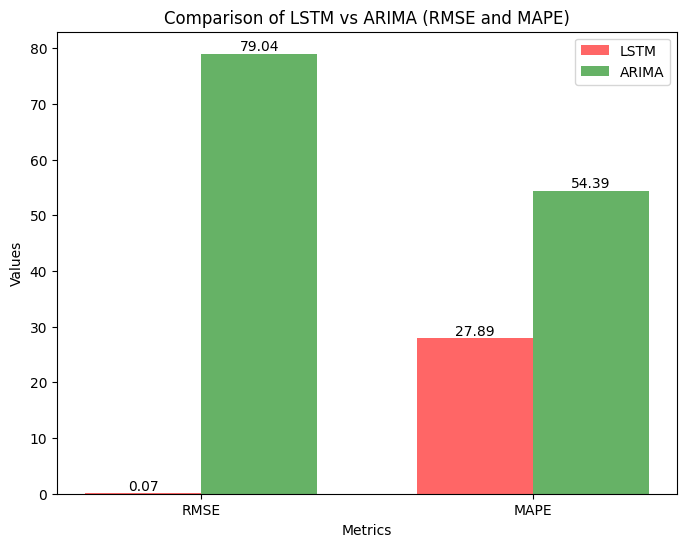

In [91]:
metrics_names = ['RMSE', 'MAPE']
lstm_metrics = [rmse_lstm, mape_lstm]
arima_metrics = [rmse_arima, mape_arima]

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Bar plot for LSTM and ARIMA
bar_width = 0.35
index = range(len(metrics_names))

# Plot LSTM and ARIMA metrics side by side
lstm_bars = ax.bar(index, lstm_metrics, bar_width, label='LSTM', color='red', alpha=0.6)
arima_bars = ax.bar([i + bar_width for i in index], arima_metrics, bar_width, label='ARIMA', color='green', alpha=0.6)

# Set labels and title
ax.set_xlabel('Metrics')
ax.set_ylabel('Values')
ax.set_title('Comparison of LSTM vs ARIMA (RMSE and MAPE)')

# Set x-axis labels
ax.set_xticks([i + bar_width / 2 for i in index])
ax.set_xticklabels(metrics_names)

# Add legend
ax.legend()

# Add values on top of the bars
for bar in lstm_bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', color='black')

for bar in arima_bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', color='black')

# Show plot
plt.show()


LSTM is the better => Choosing LSTM 

### 5. Testing and analysis of the final model


In [98]:
train_dev_size = int(len(df) * 0.75)

df_train = df.iloc[:train_dev_size] 
df_test = df.iloc[train_dev_size:]

print(f"df_train shape: {df_train.shape}")
print(f"df_test shape: {df_test.shape}")

df_train shape: (11205, 1)
df_test shape: (3736, 1)


In [99]:
# Scale the data    
scaler = MinMaxScaler(feature_range =(0, 1))
scaled_train = scaler.fit_transform(df_train['Appliances'].values.reshape(-1, 1))
scaled_train = scaled_train.flatten()   

scaled_test = scaler.transform(df_test['Appliances'].values.reshape(-1, 1))
scaled_test = scaled_test.flatten()


In [100]:
lookback = 5  

X_train, y_train = create_dataset(scaled_train, lookback)
X_test, y_test = create_dataset(scaled_test, lookback)

X_train = X_train.unsqueeze(-1)  # Shape becomes [batch, seq_len, features]
X_test = X_test.unsqueeze(-1)

print(f"X_train shape: {X_train.shape}")  # Should be [samples, lookback, 1]
print(f"y_train shape: {y_train.shape}")  # Should be [samples, 1]
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: torch.Size([11200, 5, 1])
y_train shape: torch.Size([11200, 1])
X_test shape: torch.Size([3731, 5, 1])
y_test shape: torch.Size([3731, 1])


Device: cuda


  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:01<01:46,  1.07s/it]

Epoch: 0, Loss: 0.014109
Epoch: 0, Train Loss: 0.011898, Dev Loss: 0.008901


 21%|██        | 21/100 [00:23<01:29,  1.13s/it]

...

 61%|██████    | 61/100 [01:07<00:35,  1.11it/s]

Epoch: 60, Loss: 0.005449
Epoch: 60, Train Loss: 0.005508, Dev Loss: 0.004391


 81%|████████  | 81/100 [01:27<00:20,  1.09s/it]

Epoch: 80, Loss: 0.005428
Epoch: 80, Train Loss: 0.005402, Dev Loss: 0.004270


100%|██████████| 100/100 [01:47<00:00,  1.08s/it]


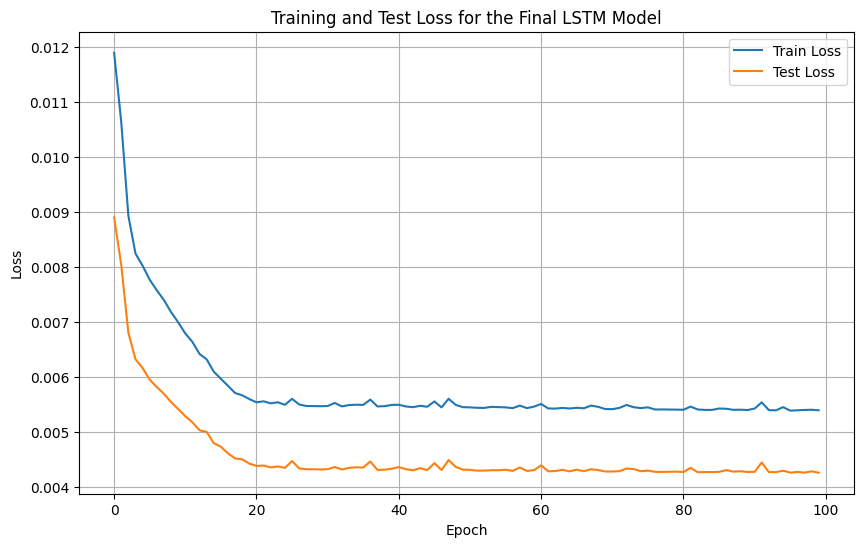

In [102]:
# Model parameters
input_size = 1
hidden_layer_size = 100
output_size = 1
num_layers = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyLSTM(input_size, hidden_layer_size, output_size, num_layers)

# Move model to the device
print(f"Device: {device}")
model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

loader = data_utils.DataLoader(data_utils.TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

training_history = []

n_epochs = 100
for epoch in tqdm(range(n_epochs)):
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    epoch_loss = sum(batch_losses) / len(batch_losses)
    
    if epoch % 20 == 0:
        print(f'Epoch: {epoch}, Loss: {epoch_loss:.6f}')
    
    # Evaluation step
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train)
        y_pred_dev = model(X_test)
        loss_train = loss_fn(y_pred_train, y_train)
        loss_dev = loss_fn(y_pred_dev, y_test)
        
        training_history.append((loss_train.item(), loss_dev.item()))
        
        if epoch % 20 == 0:
            print(f'Epoch: {epoch}, Train Loss: {loss_train.item():.6f}, Dev Loss: {loss_dev.item():.6f}')

# Prepare data for plotting
train_losses = [loss_train for loss_train, _ in training_history]
dev_losses = [loss_dev for _, loss_dev in training_history]

# Save to JSON
training_history_dict = {
    'train': train_losses,
    'test': dev_losses
}

with open('training_history_final.json', 'w') as f:
    json.dump(training_history_dict, f)

# Save the model
torch.save(model.state_dict(), 'lstm_model_final.pth')

# Plot the training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(dev_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss for the Final LSTM Model')
plt.legend()
plt.grid(True)
plt.show()

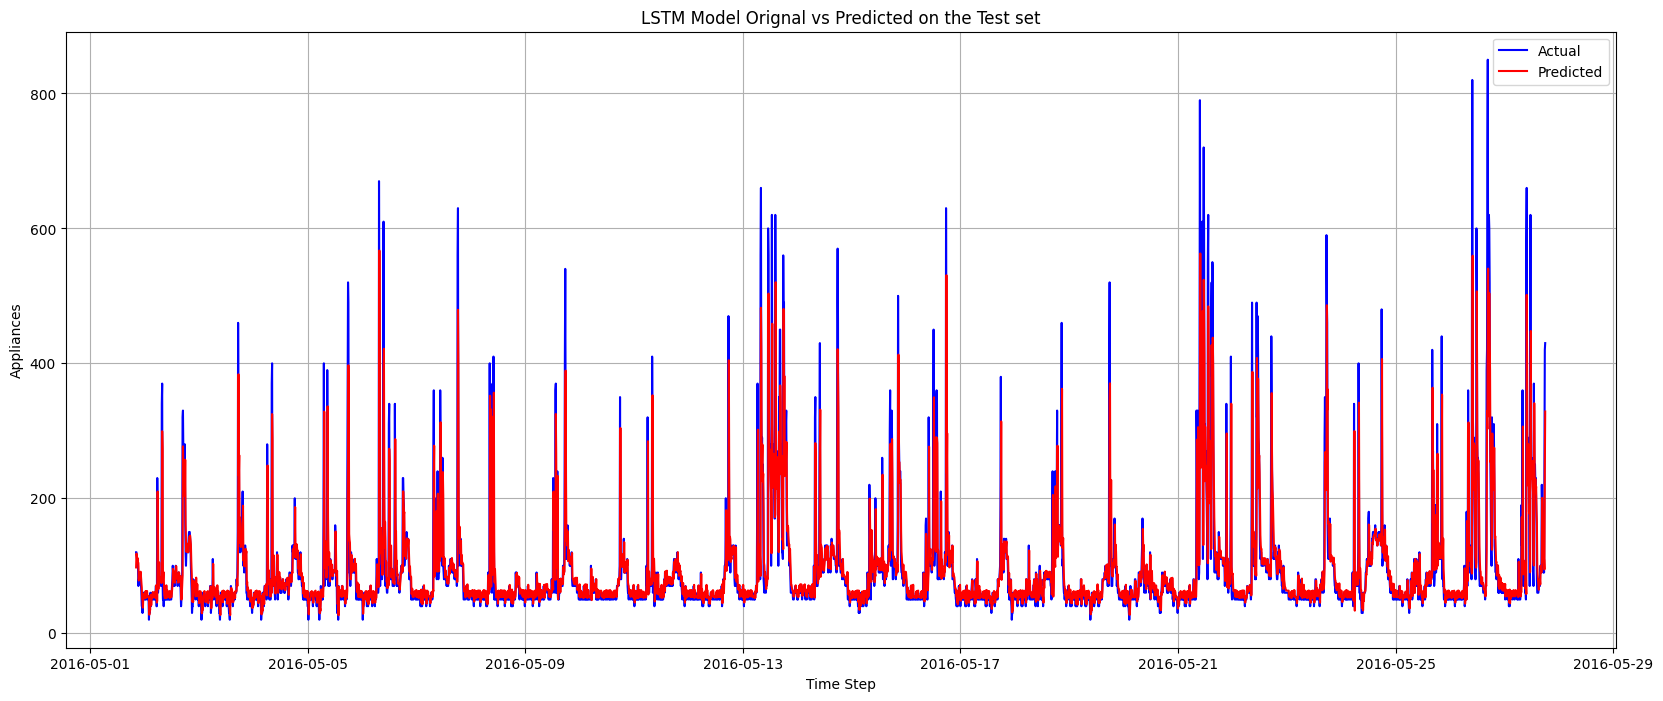

In [105]:
# Ensure model is in evaluation mode
model.eval()

# Make predictions
with torch.no_grad():
    y_pred_test = model(X_test)

# Move predictions back to CPU and convert to NumPy
y_pred_test = y_pred_test.to('cpu').numpy()
# y_test = y_test.to('cpu').numpy()

# Reshape to match the expected input of inverse_transform
y_pred_test_inv = scaler.inverse_transform(y_pred_test)
y_test_inv = scaler.inverse_transform(y_test)

time_steps = df_test.index[lookback:]  # Drop the first lookback values as they were used for prediction

plt.figure(figsize=(20, 8))
plt.plot(time_steps, y_test_inv, label='Actual', color='blue')
plt.plot(time_steps, y_pred_test_inv, label='Predicted', color='red')
plt.xlabel('Time Step')
plt.ylabel('Appliances')
plt.title('LSTM Model Orignal vs Predicted on the Test set')
plt.legend()
plt.grid(True)
plt.show()

In [106]:
rmse_lstm = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test))
mape_lstm = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print(f'Final LSTM RMSE: {rmse_lstm}')
print(f'Final LSTM MAPE: {mape_lstm}')

Final LSTM RMSE: 0.06524455867588294
Final LSTM MAPE: 26.486685872077942


### 6. Reflection

### 7. References

### 8. Appendix